In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
!pip install shap
import shap

In [2]:
df = pd.read_csv('bank-additional-full.csv',sep=';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


#  Exploratory Data Analysis



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

У даних відсутні пропущені значення, але є значення unknown.

Тобто дані не заповнені і з ними треба провести роботу по заміні їх на ті що частіше зустрічаються.

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Аналізуючи числові показники можна зазначити наступне:
- середній вік опитуваних осіб становить 40 років що є близько до 50% (38). Також враховуючи максимальний вік 98 років та 75% видно що за віком є довгий хвіст до максимально значення.
- тривалість останього контакту у секундах також показує що наявний довгий хвіст від 75% (319 с) до максимально значення (4918 с) відповідно наявні значні викиди
- кількість контактів по поточній копманії також мають значні викиди адже 75% та максимальне значення значно відрізняється, тобто з кимось контактували 56 разів при тому що в середньому з одною особою контактували близько 3 разів.


Проаналізуюмо % показників у цільовій колонці

In [6]:
df['y'].value_counts(normalize = True).sort_values(ascending = False) * 100

,proportion
y,
no,88.734583
yes,11.265417


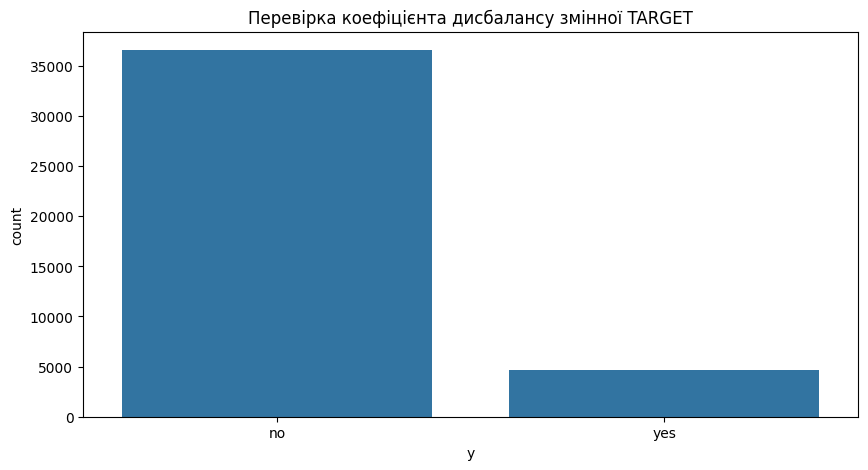

In [7]:
plt.figure(figsize = (10,5))
sns.countplot(x = df['y'], data = df)
plt.title('Перевірка коефіцієнта дисбалансу змінної TARGET')
plt.show()

У даних спостерігається дисбаланс у змінній у на основі % спостережень
Значення у no - це клієнт, який Не оформить строковий депозит. Це  88,7% даних

Значення у yes - це клієнт, який оформить строковий депозит. Це  11.3% даних

In [8]:

def bi_cat_countplot(df, column, hue_column):
    unique_hue_values = df[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,6)

    pltname = f'Нормалізований розподіл значень за категорією: {column}'
    proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[0], title=pltname)


    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f}%')

    pltname = f'Кількість даних за категорією: {column}'
    counts = df.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container)


def uni_cat_target_compare(df, column):
    bi_cat_countplot(df, column, hue_column='y' )


def bi_countplot_target(df0, df1, column, hue_column):
  pltname = 'Клієнт які оформлять строковий депозит'
  print(pltname.upper())
  bi_cat_countplot(df1, column, hue_column)
  plt.show()

  pltname = 'Клієнти які не оформлять строковий депозит'
  print(pltname.upper())
  bi_cat_countplot(df0, column, hue_column)
  plt.show()

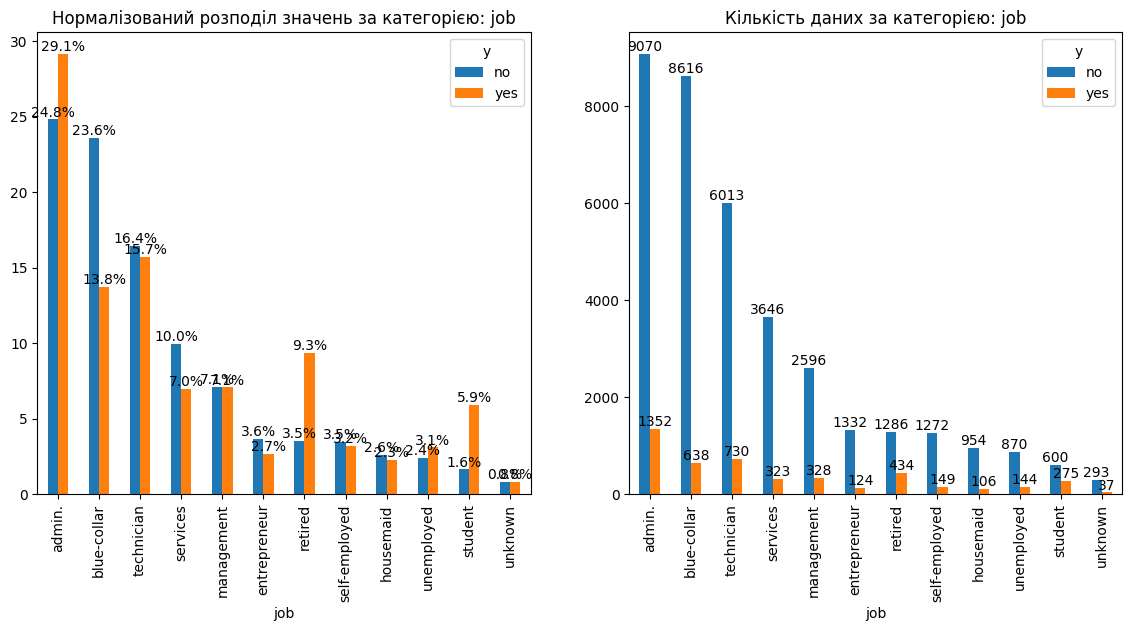

In [9]:
uni_cat_target_compare(df, 'job')

Серед осіб які відкрили депозит більша кількість відноситься до таких категорій job як: admin - 29,1 % , technicanian -  15,7 %, blue-collar - 13.8%. Тобто особи відповідно до роботи мають більший дохід.

Дивним є те що особи retired та student займають значну частку черед тих хто відкрив депозит, адже ці категорії не мають високих доходів (або взагалі не мають доходів).





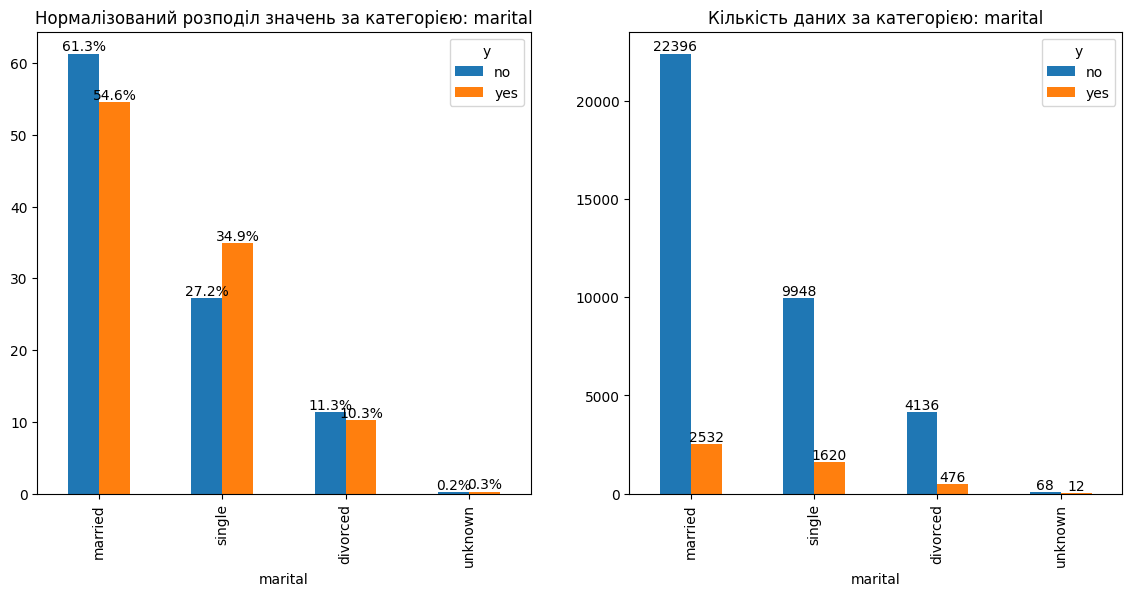

In [10]:
uni_cat_target_compare(df, 'marital')

Серед осіб які відкрили депозит  найбільша частка саме тих хто перебуває у шлюбі (54,6%) але це здебільшого за рахунок їх чисельності у даних (їх найбільше), серед тихз хто не відкриває депозит  найбільше також  тих хто у шлюбі (61,3%).
Самотні займають 2 місце  - 34,9 %, при тому що серед тих хто не відкриває депозит  самотні займають 27,2%, що є меншим за відсоток серед тих хт відкриває.
Тобто самотні частіше відкривають депозит.

Розлучені найрідше відкривають депозит - 10,3%

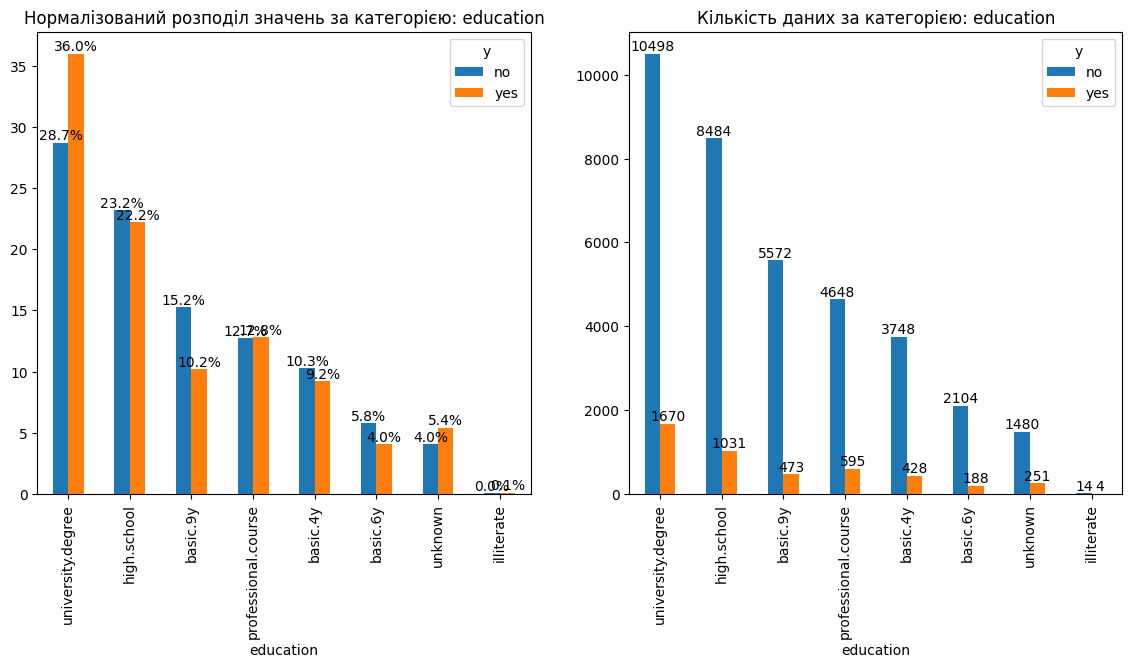

In [11]:
uni_cat_target_compare(df, 'education')

Відповідно до даних розподілу особи з університетскою освітою займають найбільший % серед тих хто відкрив депозит, при тому що % серед тих хто не відкриває депози по цій категорії є меншим 28,7%. (Це важлива ознака).
Також значний % серед тих хто відкриває депозит особи з освітнім рівнем - старша школа ( 22,2%), далі особи з професійними курсам (12,8%).
Ця тенденція здебільшого аргументована кількістю представлення певних категорій у даних.

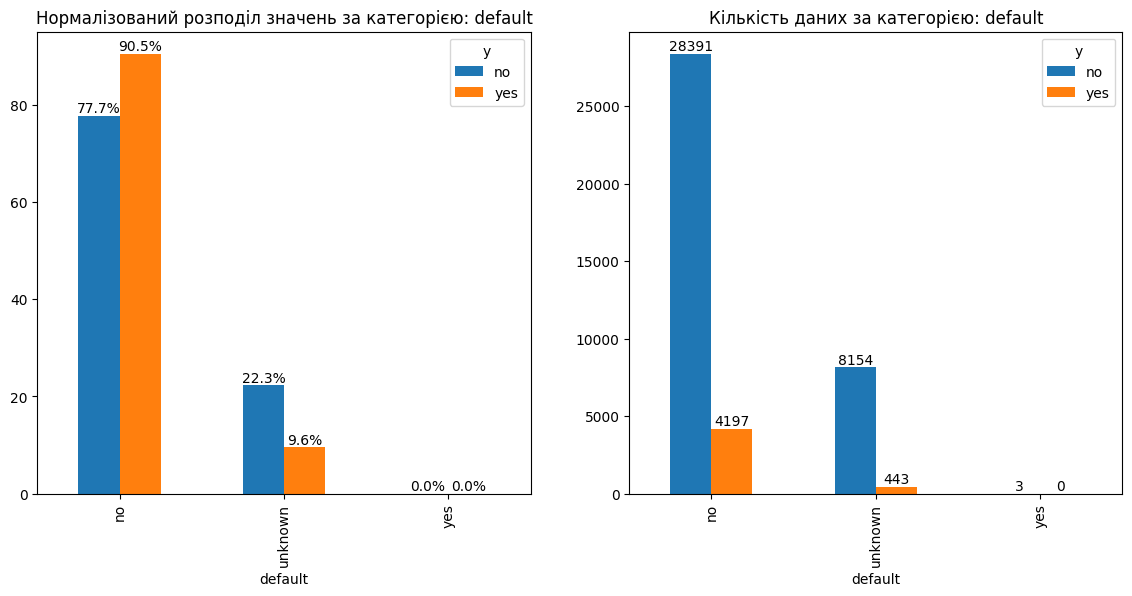

In [12]:
uni_cat_target_compare(df, 'default')

Категорія наявність просроеного кредиту не є дуже показовою адже представників які мають таку майже немає. І відповідно якщо особа має прострочений кредит наврядже в неї є зайві кошти на відкриття депозиту.

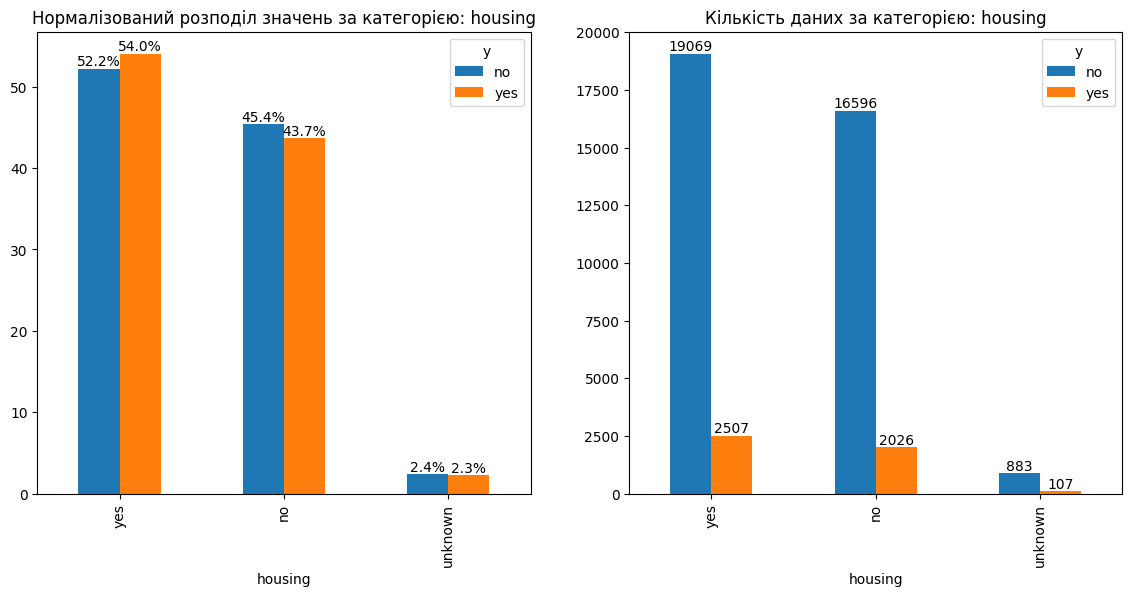

In [13]:
uni_cat_target_compare(df, 'housing')

Ознака наявність іпотечного кредиту не є дуже показовою адже %  по категоріям майде однакові.

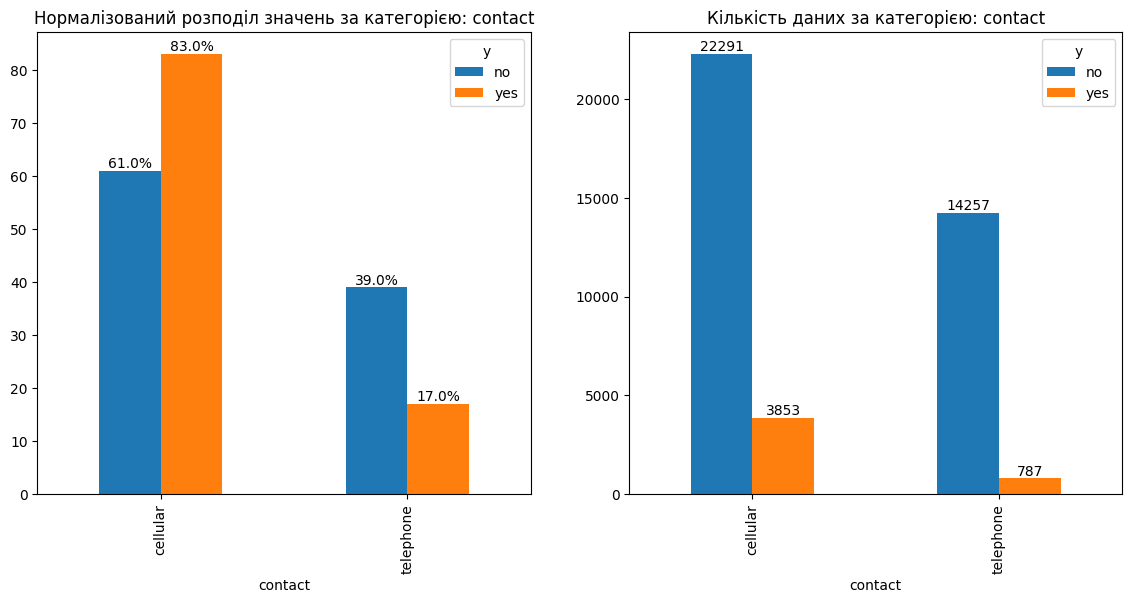

In [14]:
uni_cat_target_compare(df, 'contact')

Відповідно до даних особи які контактували за допомогою мобільного телефону більш частіше відкривають депозит серед всіх хто відкриває депозит. При цьому % тих хто не відкриває депозит серез тих хто зв'язувався через мобільний менша ніж ті що відкривають

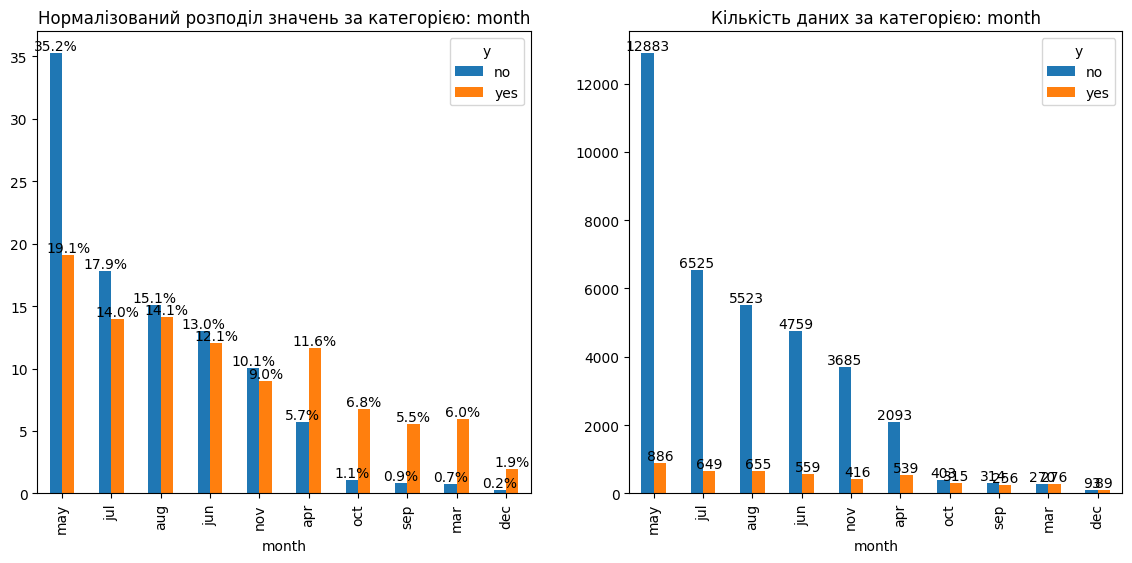

In [15]:
  uni_cat_target_compare(df, 'month')

Відповідно спостережень порівняння часток у загальному розподілі такі місяці як квітень, жовтень, вересень, березень та грудень є найменшими за проведеними компаніями але більш результативними.

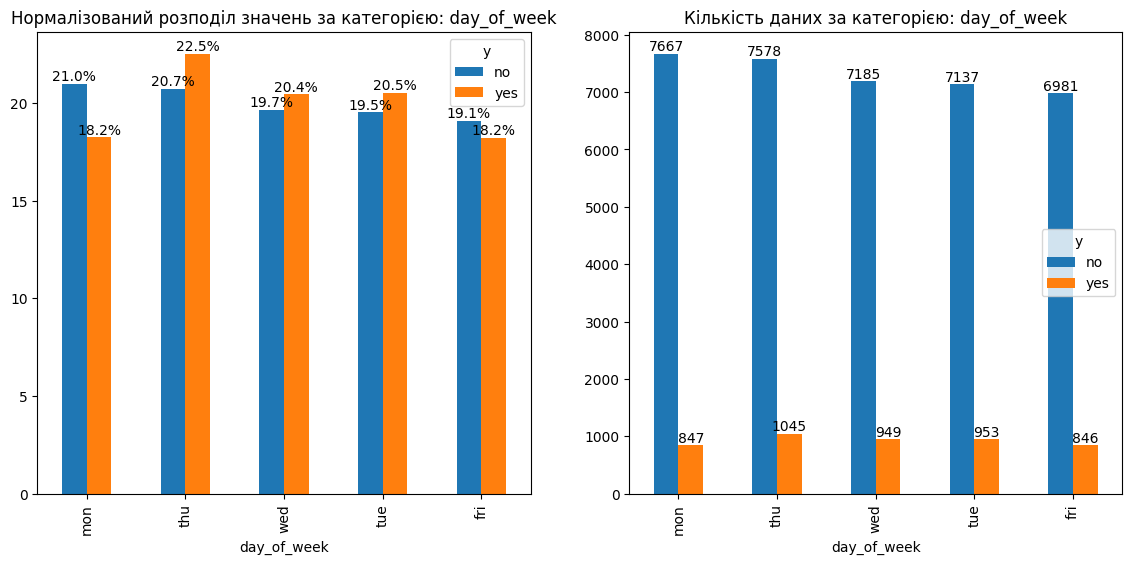

In [16]:
uni_cat_target_compare(df, 'day_of_week')

Відповідно даних день тижня останього контакту більш меншь однакові і якоюсь закономірності не спостерігається

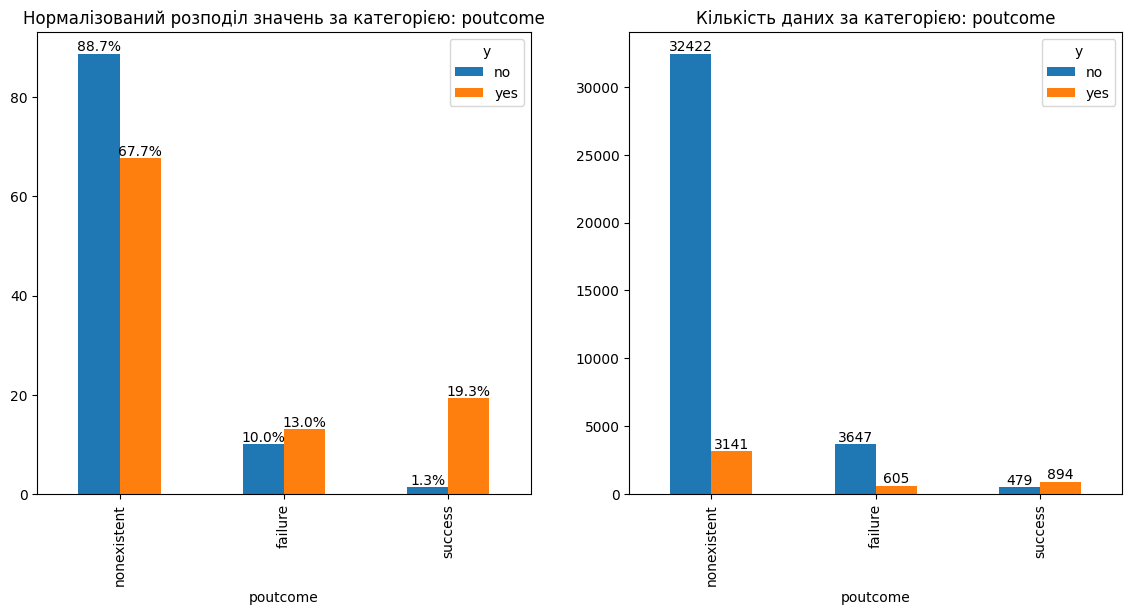

In [17]:
uni_cat_target_compare(df, 'poutcome')

Відповідно аналізу видно що при успішній попередній кампанії більша частка осіб знову відкриває депозит.

Найбільша частка осіб яких обдзвонюють вперше приймають уччасть у маркетинговій компанії і порівняно з часткою то більшість відмовляютьсявідкривати депозит

Замінимо значення у цільовій колонці на числові для зручності використання у кореляційному аналізі

In [18]:
df['y'] = np.where(df['y'] == 'yes', 1, 0)

In [19]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1


In [20]:
def analyz_column_one_vym(df, column):
    df0 = df[df['y'] == 0]
    df1 = df[df['y'] == 1]

    Q1_0 = df0[column].quantile(0.25)
    Q3_0 = df0[column].quantile(0.75)
    IQR0 = Q3_0 - Q1_0
    Max_value_0 = Q3_0 + 1.5 * IQR0

    Q1_1= df1[column].quantile(0.25)
    Q3_1 = df1[column].quantile(0.75)
    IQR1 = Q3_1 - Q1_1
    Max_value_1 = Q3_1 + 1.5 * IQR1

    plt.figure(figsize=(14, 6))
    sns.kdeplot(df1[df1[column] <= Max_value_1][column], label='Особи які відкрили депозит')
    sns.kdeplot(df0[df0[column] <= Max_value_0][column], label='OОсоби які не відкрили депозит')
    plt.ticklabel_format(style='plain', axis='x')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()


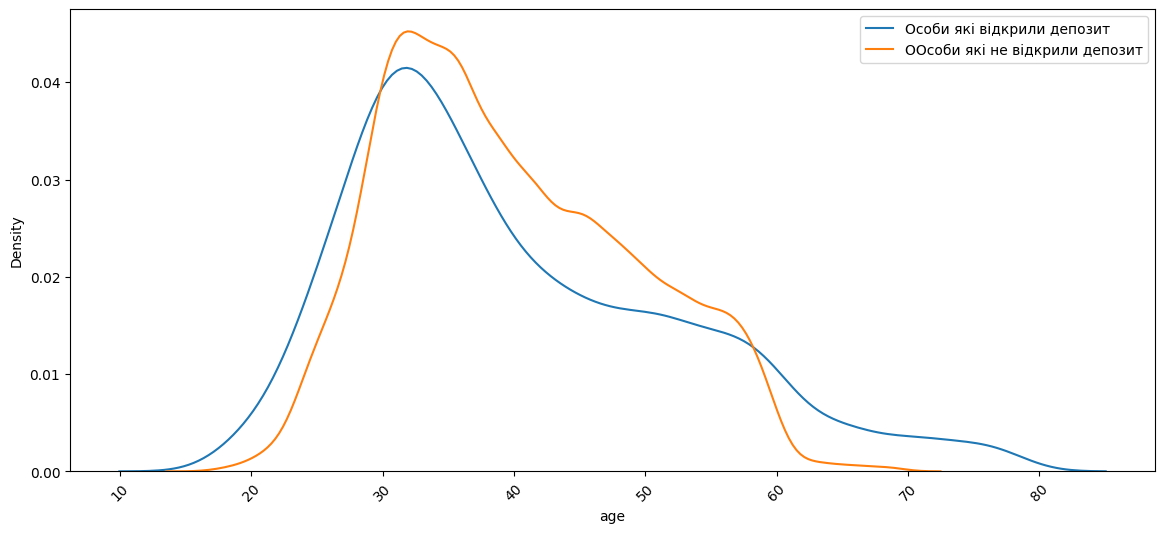

In [21]:
analyz_column_one_vym(df,'age')

У віці до 20 років бльшіст осівідкривають депозит,у віці з 30 до 60 більшіть осіб відмовяються від відкриття депозиту, і у віці біьше 60 частк тих хто відкриває депотип перевищує тих хто відмовився.Відповідно прямої залежості (збільшеня віку і збільшення осіб, хто відкрива кредити) немає.

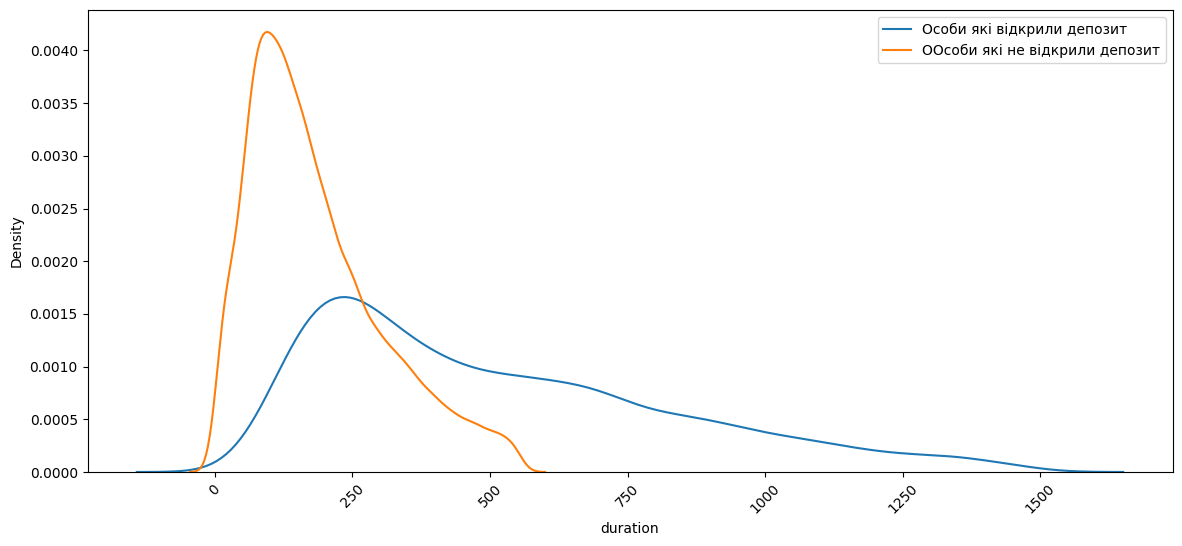

In [22]:
analyz_column_one_vym(df,'duration')

Відповідно спостереження,чим довше тривалість останього контакту тим більша ймовірність що особа відкриє депозит. так при тривалості контакту більше 250 секунд, особа приймає рішення про відкриття депозиту (можливо отримує доастатньо інформації для цього)

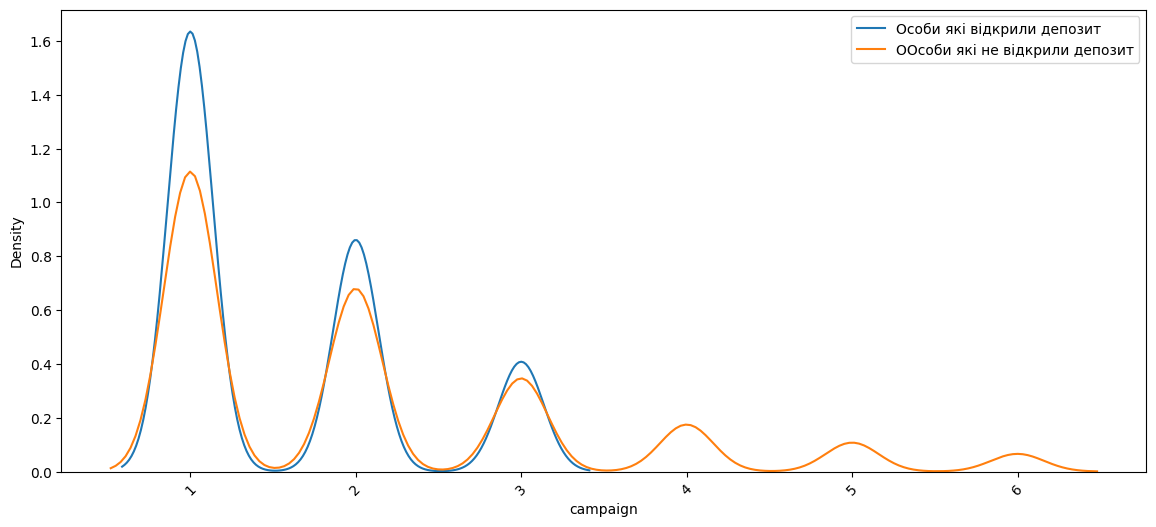

In [23]:
analyz_column_one_vym(df,'campaign')

Аналізуючи дані видно що більша ймовірність особи відкрити депозит була підчас 1-3 контактів (при тому з кожним наступним разом ймовірність зменшилась. після 3 контакту не спостерігається ймовірності що особа відкриє депозит, що логічно адже нав'язливі дзвінки набридають і не приводять до необхідного результату.

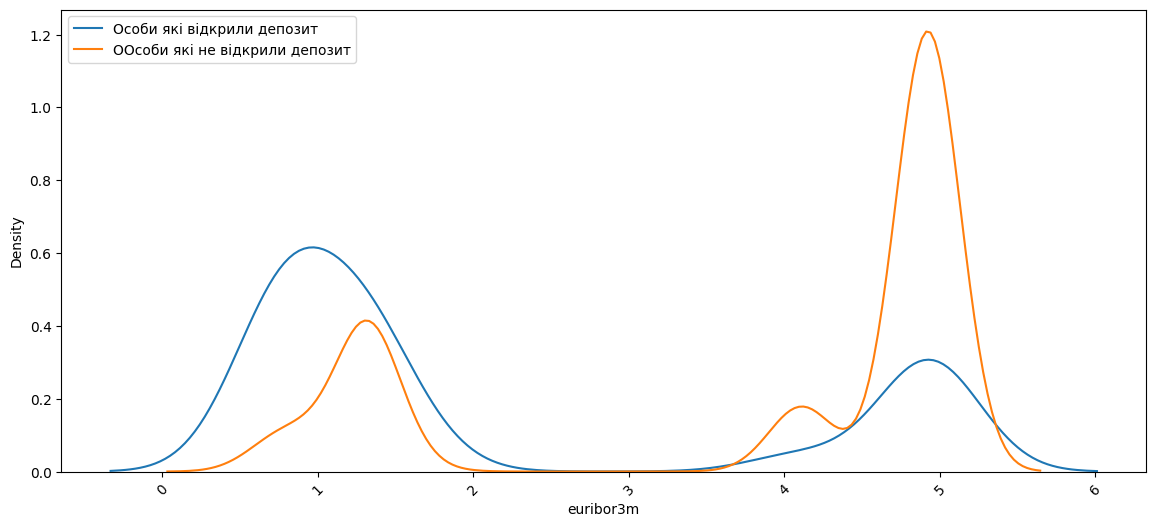

In [24]:
analyz_column_one_vym(df,'euribor3m')

відповідно до даних пр низкій ставці Euribor на 3 місяці більше ймовірність відкрити депозит, відповідно чим більша ставка тим ймовірність менша.

Також необхідно провести кореляційний аналіз вплик=ву зміни числових показників на цільову зммінну у.

<Axes: >

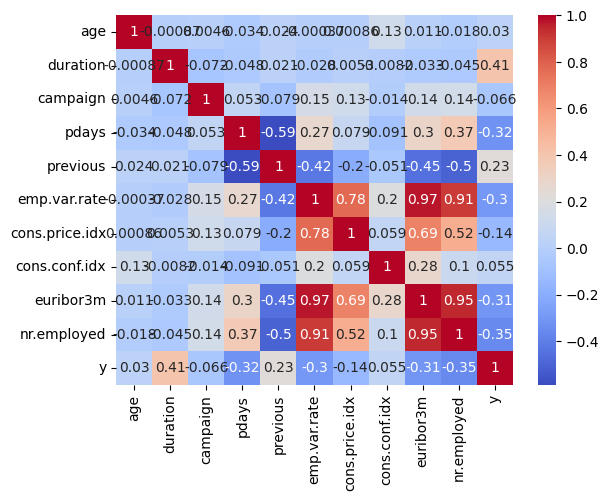

In [25]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

Проаналізувавши кореляційну матрицю можна зазначити наступні оказники які маюь значний вплив на цільову змінну:
- duration (позитивна кореляція), підвищення тривалості дзвінка впливає на збільшення ймовірності відкриття депозиту (дізнаються більше інформації)
-previous (позитивна кореляція), підвищення кількості контактів до поточної компанії впливає на збільшення ймовірності відкриття депозиту (вже чули про цю компанію)
- nr.employed (негативна кореляція), зменшення кількості працевлаштованих осіб підвищує ймовірність відкриття депозиту
- euribor3m (негативна кореляція) зменшення ставки Euribor на 3 місяці підвищує ймовірність відкриття депозиту
- pdays -  (негативна кореляція), зменшення кількості днів від останього контакту підвищує ймовірність відкриття депозиту.

Також аналізуючи дані видно, що показники euribor3m, nr.employed та emp.var.rate сильно корелюють між собою, що може негативно вплинути на результат, отже треба залишити тільки один з цих показників

У висновок можна зазначити критерії які можуть позитивно вплинути на прийняття рішення по відкриттю депозита:
- особа має такі види зайнятості  admin, technicanian, blue-collar. (добре оплачувана робота)
- особа яка має університетську освіту або освіту вищої школи
- особа яка контактує за допомогою мобільного телефону
- особи які вже мали досвід відкриття депозиту у попередній маркетинговій компанії
- особи до 30 або після 60 років
- особи з якими спілкувались більше 250 с, але при тому контактували не більше 3 разів
- низька ставка Euribor на 3 місяці

Відповідно до того що у даних спостерігається сильний дисбаланс по цільовій категорії (тільки 11% відкривають депозит) показник Accuracy використовувати не варто адже при вказанні, що особа не відкриє депозит точність буде високою  - 89% але не показовою для реального використання.
Будемо використовувати показник ROC-AUC для більш точної оцінки або f1.

Так як цільова змінна має 2 категорії (1 та 0), доцільно використовувати наступні методі машиного навчання:
- логістична регресія
- дерево прийняття рішень,



In [26]:
from bank_additional import preprocess_data

In [27]:
X_train, y_train, X_val, y_val, X_test, y_test, input_cols, scaler, encoder = preprocess_data(df)

Тренеруємо модель логістичної регресії

In [28]:
log_reg = LogisticRegression(solver='liblinear',class_weight='balanced',random_state=42)
log_reg.fit(X_train,y_train)
val_preds = log_reg.predict(X_val)
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92      5468
           1       0.44      0.87      0.58       694

    accuracy                           0.86      6162
   macro avg       0.71      0.86      0.75      6162
weighted avg       0.92      0.86      0.88      6162



In [29]:
def predict_(model, inputs, targets, name=''):
    preds = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")

In [30]:
train_preds = predict_(log_reg, X_train, y_train, 'Training')
val_preds = predict_(log_reg, X_val, y_val, 'Validation')
test_preds = predict_(log_reg,  X_test, y_test, 'Test')

Area under ROC score on Training dataset: 0.93
Area under ROC score on Validation dataset: 0.93
Area under ROC score on Test dataset: 0.94


Відповідно показника roc_auc на тренувальних даних показник = 93%, валідаційні - 93% та тестові 94%, то модель є дуже гарна і ознаки перенавчання відсутні

Тренуємо модель kNN

In [31]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 50)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

In [32]:
knn_best = knn_gs.best_estimator_
knn_best

KNeighborsClassifier(n_neighbors=np.int64(48))

In [33]:
train_preds = predict_(knn_best, X_train, y_train, 'Training')
val_preds = predict_(knn_best, X_val, y_val, 'Validation')
test_preds = predict_(knn_best,  X_test, y_test, 'Test')

Area under ROC score on Training dataset: 0.86
Area under ROC score on Validation dataset: 0.79
Area under ROC score on Test dataset: 0.81


Результати навчання моделі kNN доволі непогані, але гірші за результати  логістичного регресії. Також показник roc_auc для тренувальних даних (86%) більший за валідаційний (79%), та тестувальний (81%), тобто спостерігаються незначні ознаки перенавчання моделі.

Тренуємо модель Decision Tree

In [34]:
Decision_Tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}
grid_search = GridSearchCV(estimator=Decision_Tree,param_grid=param_grid,cv=3,scoring='roc_auc')

In [35]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [36]:
random_search = RandomizedSearchCV(Decision_Tree, param_distributions=params_dt, n_iter=40, cv=3, scoring='roc_auc', random_state=42)

In [37]:
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [38]:
dt_random_search_best =  random_search.best_estimator_

In [39]:
train_preds = predict_(dt_random_search_best, X_train, y_train, 'Training')
val_preds = predict_(dt_random_search_best, X_val, y_val, 'Validation')
test_preds = predict_(dt_random_search_best,  X_test, y_test, 'Test')

Area under ROC score on Training dataset: 0.93
Area under ROC score on Validation dataset: 0.93
Area under ROC score on Test dataset: 0.94


Результати тренування моделі Decision Tree з використання підбору параметрів RandomizedSearchCV показали аналогічні результати як і логістична регресія і кращі за метод kNN. Перенавчання також не спостерігається.

Тренування алгоритму XGBoostClassifier з використанням бібліотеки пошуку гіпер параметрів Hyperopt

In [40]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=10
    )

    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val), (X_test,  y_test)],
        verbose=False)

    y_pred_proba = clf.predict_proba(X_val)[:, 1]
    auc_score = roc_auc_score(y_val, y_pred_proba)


    return {'loss': -auc_score, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda',
)

final_clf.fit(X_train, y_train,)

train_preds = predict_(final_clf , X_train, y_train, 'Training')
val_preds = predict_(final_clf , X_val, y_val, 'Validation')
test_preds = predict_(final_clf,  X_test, y_test, 'Test')

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:19] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:19] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



  5%|▌         | 1/20 [00:03<01:11,  3.75s/trial, best loss: -0.949582743929048]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:23] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:23] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:04<00:35,  1.96s/trial, best loss: -0.949582743929048]

...

 95%|█████████▌| 19/20 [00:29<00:02,  2.31s/trial, best loss: -0.9496061971249017]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:49] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:49] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:30<00:00,  1.52s/trial, best loss: -0.9496061971249017]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.8259351675636171), 'gamma': np.float64(0.24487485092781786), 'learning_rate': np.float64(0.08863921968093902), 'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 350, 'reg_alpha': np.float64(0.8980006701651116), 'reg_lambda': np.float64(0.1854974501749974), 'subsample': np.float64(0.8189650451935616)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:49] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:49] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Area under ROC score on Training dataset: 0.99
Area under ROC score on Validation dataset: 0.94
Area under ROC score on Test dataset: 0.95


Алгоритм бустингу XGBoostClassifier з використанням бібліотеки пошуку гіпер параметрів Hyperopt є найбільш якісною серед інших моделей адже результат на валідаційних та тестових даних становить 95%. Тобто з вирогідністю 95% аргоритм вкаже особу яка відкриє депозит

In [41]:
xgb_clf = XGBClassifier(
    max_depth=4,
    n_estimators=20,
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda'
)

xgb_clf.fit(X_train, y_train)

train_pred = xgb_clf.predict( X_train)
val_pred = xgb_clf.predict( X_val)
test_pred = xgb_clf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:52] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:52] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [42]:
params_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': np.arange(3, 10),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.4]
}

In [43]:
xgb_random_search  = RandomizedSearchCV(xgb_clf, param_distributions=params_xgb, n_iter=20, cv=3, scoring='roc_auc', random_state=42)

In [44]:
xgb_random_search.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:53] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:53] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:55] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-pack

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrai...
                                           monotone_constraints=None,
                                           multi_strategy=None, n_estimators=20,
                                           n_jobs=None, num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc')

In [45]:
dt_random_search_best =  xgb_random_search.best_estimator_

In [49]:
dt_random_search_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(6), max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=200, n_jobs=None, num_parallel_tree=None, ...)

In [46]:
train_preds = predict_( dt_random_search_best , X_train, y_train, 'Training')
val_preds = predict_( dt_random_search_best , X_val, y_val, 'Validation')
test_preds = predict_( dt_random_search_best,  X_test, y_test, 'Test')

Area under ROC score on Training dataset: 0.97
Area under ROC score on Validation dataset: 0.95
Area under ROC score on Test dataset: 0.96


Результати алгоритму XGBoostClassifier з використанням Sklearn: Randomized Search дали ще кращі результати адже на тестових даних показник roc_auc становить 96% тобто поки це найкращиц результат показника на тестових даних.

Аналізуємо важливість ознак для моделі

In [47]:
importances =dt_random_search_best.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


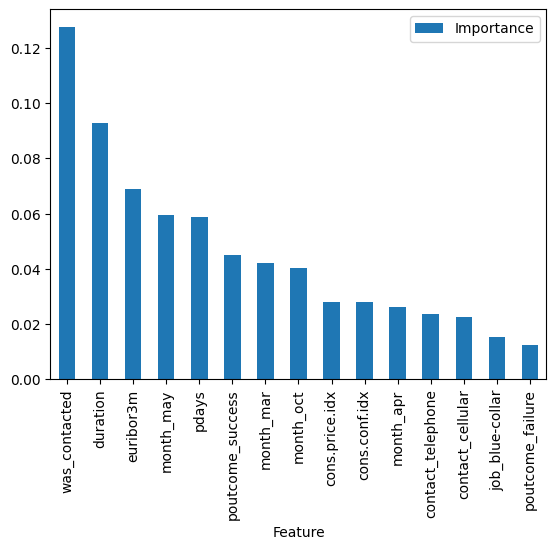

In [48]:
feature_importance_df.head(15).set_index('Feature').plot.bar();

Найважливішими ознаками є:
- was_contated (створена знака 1 був контакт з особою,0 ні) найвпливовіша ознака так як особа вже знайома з компанією, і швидше піде на контакт і можливо відкриє депозит
- duration. ознака є важливою, що і видно з EDA. чим довше тримає розмова тим більше інформації про депозит отримає людина і більша ймовірність відкрити депозит
- euribor3m ьтакож важлива ознака що і визначала вплив на цільову змінну при EDA
- pdays ознака є джерелом колонки  was_contated кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії
-month_may - цікава ознака, що свідчить про те що особи які мали останній контакт у травні  є більш важливими ніж у інші місяці (можливо на це впливала наприклад гарна ставка euribor3m)
Всі ознаки є логічними та відповідають проведеному EDA/

**Проводимо аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.**

In [51]:
explainer = shap.TreeExplainer(dt_random_search_best)
shap_values = explainer.shap_values(X_train)

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train.iloc[0,:])

Відповідно аналізу впливу ознак на передбачання за допомогою бібліотеки SHAP видно, що:
- базове значення Base Value становить -2,102 від якого йде відлік і на яке впливають показники
- отриманий результат для обраної особи f(x)=−5.09, це значення далі від базового отже особа не відкриє депозит

- найбільший вплив на прийняття (негативного рішенні) має euribor3m  (0,
9816) ставка є мабуть в час проведення компанії високою
- далі також впливає тривалість дзвінка (0,0486) скоріше тривалість була низька (що видно нижче у переліку значення 0,0485 доволі далеко від 1)
- ознаки, які б вплинули на відкриття депозиту дуже малі (майже не видно)


In [52]:
X_train.iloc[0,:]

,21817
age,0.172840
duration,0.048597
campaign,0.000000
pdays,1.000000
previous,0.000000
cons.price.idx,0.484412
cons.conf.idx,0.615063
euribor3m,0.981637
was_contacted,0.000000
job_admin.,0.000000


Аналіз записів, в яких модель помиляється

In [55]:
error_df = X_test.copy()
error_df['real'] = y_test
error_df['predicted'] = final_clf.predict(X_test)

In [57]:
errors = error_df[error_df['real'] != error_df['predicted']]
errors

,age,duration,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m,was_contacted,job_admin.,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,real,predicted
6520,0.493827,0.110411,0.166667,1.0,0.000000,0.698753,0.602510,0.957379,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0
28743,0.197531,0.057950,0.000000,1.0,0.000000,0.340608,0.154812,0.175924,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1,0
12385,0.518519,0.100447,0.500000,1.0,0.000000,0.669135,0.338912,0.980730,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0
24430,0.259259,0.219805,0.000000,1.0,0.142857,0.389322,0.368201,0.806393,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
38769,0.320988,0.035990,0.000000,1.0,0.142857,0.174591,0.866109,0.018136,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29926,0.456790,0.172224,0.666667,1.0,0.000000,0.340608,0.154812,0.174790,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1
29165,0.506173,0.169581,0.000000,1.0,0.000000,0.340608,0.154812,0.174790,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1
16349,0.172840,0.326962,1.000000,1.0,0.000000,0.669135,0.338912,0.980957,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0
20526,0.172840,0.113664,0.166667,1.0,0.000000,0.484412,0.615063,0.982090,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0


Відповідно даних по деяких клієнтам (модель вказала 0, а реальна змінна 1) через  низька тривалість розмови та високий euribor3m.
По деяких клієнтам ситуація навпаки (модель вказала 1, а реальна змінна 0) тривалість розмови була висока і був попередній контакт.

Тобто можна частину помилок віднести на аномальну поведінку, або неодостатність інформації

Для покращення моделі можливо необхідні додаткові показники, або проаналізувати показники тільки тих клієнтів які мали контакт, що дозволить краще зрозуміти вплив змінних. також можливим варіантом є попрацювати з параметрами моделей